# Brain Tumor Segmentation using nnU-Net

This notebook demonstrates how to use nnU-Net (no-new-UNet) for automatic brain tumor segmentation on the BraTS2020 dataset.

## What is nnU-Net?
nnU-Net is a self-configuring deep learning framework for medical image segmentation. It automatically adapts to any new dataset and determines the preprocessing, network architecture, training, and post-processing pipeline.

## Dataset: BraTS2020
- **Modalities**: 4 MRI sequences (FLAIR, T1, T1CE, T2)
- **Classes**: Background, Edema, Non-enhancing tumor, Enhancing tumor
- **Task**: Segment brain tumors from multi-modal MRI scans

---
## 1. Environment Setup

### Installing Required Libraries
We need to install PyTorch and the hiddenlayer library for network visualization.

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 72.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 36.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 92.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 29.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 8.3 MB/s eta 0:00:000

In [2]:
!cp -r "/kaggle/input/nnunet-3/nnUNet" "/kaggle/working/"

In [3]:
%cd nnUNet
!pip install -e .

/kaggle/working/nnUNet
Obtaining file:///kaggle/working/nnUNet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 80.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 85.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 4.6 MB/s eta 0:00:00
  Building editable for nnunetv2 (pyproject.toml) ... done
 

In [4]:
!pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git


  Cloning https://github.com/FabianIsensee/hiddenlayer.git to /tmp/pip-req-build-lynocdlc
  Running command git clone --filter=blob:none --quiet https://github.com/FabianIsensee/hiddenlayer.git /tmp/pip-req-build-lynocdlc
  Resolved https://github.com/FabianIsensee/hiddenlayer.git to commit b7263b6dc4569da1b6dea5964e1eac78fa32fa77
  Preparing metadata (setup.py) ... done
  Created wheel for hiddenlayer: filename=hiddenlayer-0.2-py3-none-any.whl size=20004 sha256=9e0e2f33742c034e9049a86b38d8acd0cbf58ca139e991340b913e440342e1fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-3m_5i6yo/wheels/5e/bb/33/76bf11a993485ba52708dbbb7f9612cbb8bb640d4580967ab1
Successfully built hiddenlayer


---
## 2. Setting Up nnU-Net Directory Structure

### nnU-Net Folder Organization
nnU-Net expects a specific folder structure:

```
nnUNet_raw/
  └── Dataset001_BraTS2020/
      ├── imagesTr/          # Training images
      ├── labelsTr/          # Training labels
      ├── imagesTs/          # Test images (optional)
      └── dataset.json       # Dataset configuration
```

### Naming Convention
- **Images**: `CaseID_XXXX.nii` where XXXX = modality (0000, 0001, etc.)
- **Labels**: `CaseID.nii`

In [5]:
import os
from pathlib import Path
import subprocess

# Dataset identifiers
dataset_id = "001"
dataset_name = "BraTS2020"

# Source: the original dataset
input_root = Path("/kaggle/input/brats-2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

# Destination: nnU-Net raw structure
dataset_root = Path(f"/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset{dataset_id}_{dataset_name}")
imagesTr = dataset_root / "imagesTr"
labelsTr = dataset_root / "labelsTr"
imagesTr.mkdir(parents=True, exist_ok=True)
labelsTr.mkdir(parents=True, exist_ok=True)

---
## 3. Data Preparation

### Creating Symbolic Links
Instead of copying large files, we create symbolic links to save disk space. We select only 20 samples for the implementation as it takes too much time for training and don't have much disk space

### BraTS Modalities Mapping
- **0000** → FLAIR (Fluid Attenuated Inversion Recovery)
- **0001** → T1 (T1-weighted)
- **0002** → T1CE (T1-weighted with contrast enhancement)
- **0003** → T2 (T2-weighted)

We link only the first 20 cases for the demonstration



In [6]:
# Modality suffix mapping
modality_suffixes = {
    "flair": "0000",
    "t1": "0001",
    "t1ce": "0002",
    "t2": "0003"
}

# Pick only first 20 cases
all_case_dirs = sorted([d for d in input_root.iterdir() if d.is_dir()])[:20]

# Loop through selected cases
for case_dir in all_case_dirs:
    case_id = case_dir.name  # e.g., BraTS20_Training_001

    # Create symbolic links for each modality
    for modality, channel in modality_suffixes.items():
        src = case_dir / f"{case_id}_{modality}.nii"
        if src.exists():
            dst = imagesTr / f"{case_id}_{channel}.nii"
            subprocess.run(["ln", "-s", str(src), str(dst)], check=False)

    # Create symbolic link for segmentation mask
    seg = case_dir / f"{case_id}_seg.nii"
    if seg.exists():
        dst_seg = labelsTr / f"{case_id}.nii"
        subprocess.run(["ln", "-s", str(seg), str(dst_seg)], check=False)

print(f"✅ Symlinks created for {len(all_case_dirs)} BraTS2020 subjects")


✅ Symlinks created for 20 BraTS2020 subjects


---
## 4. Creating dataset.json Configuration

This file tells nnU-Net about:
- Number of input channels (modalities)
- Label classes and their meanings
- Number of training cases
- File format

### BraTS Label Structure
Original BraTS labels use: **0** (background), **1** (edema), **2** (non-enhancing), **4** (enhancing)

nnU-Net requires consecutive labels: **0**, **1**, **2**, **3**

In [7]:
import json

dataset_json = {
    "channel_names": {
        "0": "FLAIR",
        "1": "T1",
        "2": "T1CE",
        "3": "T2"
    },
    "labels": {
        "background": 0,
        "edema": 1,
        "non_enhancing_tumor": 2,
        "enhancing_tumor": 3
    },
    "regions_class_order": [1, 2, 3],
    "numTraining": len(list(labelsTr.glob("*.nii"))),
    "file_ending": ".nii",
    "overwrite_image_reader_writer": "SimpleITKIO"
}

with open(dataset_root / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print("✅ dataset.json created at:", dataset_root / "dataset.json")


✅ dataset.json created at: /kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/dataset.json


In [8]:
print("Sample image files:")
for i, f in enumerate(sorted(imagesTr.glob("*.nii"))[:8]):
    print(f"-", f.name)
print("\nSample label files:")
for i, f in enumerate(sorted(labelsTr.glob("*.nii"))[:8]):
    print(f"-", f.name)

print(f"\nTotal training subjects: {len(list(labelsTr.glob('*.nii')))}")


Sample image files:
- BraTS20_Training_001_0000.nii
- BraTS20_Training_001_0001.nii
- BraTS20_Training_001_0002.nii
- BraTS20_Training_001_0003.nii
- BraTS20_Training_002_0000.nii
- BraTS20_Training_002_0001.nii
- BraTS20_Training_002_0002.nii
- BraTS20_Training_002_0003.nii

Sample label files:
- BraTS20_Training_001.nii
- BraTS20_Training_002.nii
- BraTS20_Training_003.nii
- BraTS20_Training_004.nii
- BraTS20_Training_005.nii
- BraTS20_Training_006.nii
- BraTS20_Training_007.nii
- BraTS20_Training_008.nii

Total training subjects: 20


### Setup environment variables

In [9]:
import os

os.environ["nnUNet_raw"] = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/kaggle/working/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/kaggle/working/nnUNet_results"

print("✅ nnU-Net paths set:")
for k in ["nnUNet_raw", "nnUNet_preprocessed", "nnUNet_results"]:
    print(f"{k} = {os.environ[k]}")


✅ nnU-Net paths set:
nnUNet_raw = /kaggle/working/nnUNet_raw_data_base/nnUNet_raw
nnUNet_preprocessed = /kaggle/working/nnUNet_preprocessed
nnUNet_results = /kaggle/working/nnUNet_results


In [10]:
from pathlib import Path

dataset_root = Path("/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020")
labelsTr = dataset_root / "labelsTr"

num_cases = len(list(labelsTr.glob("*.nii")))
print(f"Total label files found: {num_cases}")


Total label files found: 20


### Find images that hsn't got labels

In [11]:
import os
import shutil
from collections import defaultdict

imagesTr_dir = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/imagesTr"
labelsTr_dir = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/labelsTr"
missing_dir = "/kaggle/working/missing_label_cases"
os.makedirs(missing_dir, exist_ok=True)

# Step 1: Collect IDs from labels
label_ids = {os.path.basename(f).replace('.nii', '') for f in os.listdir(labelsTr_dir) if f.endswith('.nii')}

# Step 2: Group image files by case ID
image_dict = defaultdict(list)
for f in os.listdir(imagesTr_dir):
    if not f.endswith(".nii"):
        continue
    base_id = "_".join(f.split('_')[:3])  # e.g. BraTS20_Training_001
    image_dict[base_id].append(f)

# Step 3: Identify cases with images but no label
extra_image_cases = [cid for cid, imgs in image_dict.items() if cid not in label_ids]

print("Extra image cases without labels:")
for c in extra_image_cases:
    print(c)
print(f"\nTotal: {len(extra_image_cases)} case(s) missing labels.\n")

# Step 4: Move extra image cases to 'missing_label_cases'
for case in extra_image_cases:
    for f in image_dict[case]:
        src = os.path.join(imagesTr_dir, f)
        if os.path.exists(src):
            shutil.move(src, os.path.join(missing_dir, f))
            print(f"Moved {f}")
        else:
            print(f"⚠️ File not found (already moved or different extension): {f}")


Extra image cases without labels:

Total: 0 case(s) missing labels.



---
## 5. Remapping BraTS Labels

BraTS uses labels **{0, 1, 2, 4}** but nnU-Net needs **consecutive** labels **{0, 1, 2, 3}**.

### Label Mapping
| Original | Tissue Type | New Label |
|----------|-------------|----------|
| 0 | Background | 0 |
| 1 | Edema | 1 |
| 2 | Non-enhancing | 2 |
| 4 | Enhancing | 3 |


In [12]:
import os
import nibabel as nib
import numpy as np

labels_dir = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/labelsTr"
fixed_dir = "/kaggle/working/nnUNet_fixed_labels"
os.makedirs(fixed_dir, exist_ok=True)

for file in os.listdir(labels_dir):
    if not file.endswith(".nii"):
        continue
    path = os.path.join(labels_dir, file)
    img = nib.load(path)
    data = img.get_fdata()

    # Check and remap class 4 → 3
    if 4 in np.unique(data):
        print(f"Fixing {file} (relabeling 4 → 3)")
        data[data == 4] = 3
    else:
        print(f"No label 4 found in {file}")

    # Save to fixed_dir
    fixed_path = os.path.join(fixed_dir, file)
    fixed_img = nib.Nifti1Image(data.astype(np.uint8), img.affine, img.header)
    nib.save(fixed_img, fixed_path)

print("✅ All label files processed and saved to:", fixed_dir)
print("➡️ Next: Update your nnUNet dataset.json to point to the fixed_dir, or copy these back into labelsTr.")


Fixing BraTS20_Training_005.nii (relabeling 4 → 3)
Fixing BraTS20_Training_006.nii (relabeling 4 → 3)
Fixing BraTS20_Training_012.nii (relabeling 4 → 3)
Fixing BraTS20_Training_018.nii (relabeling 4 → 3)
Fixing BraTS20_Training_002.nii (relabeling 4 → 3)
Fixing BraTS20_Training_017.nii (relabeling 4 → 3)
Fixing BraTS20_Training_010.nii (relabeling 4 → 3)
Fixing BraTS20_Training_016.nii (relabeling 4 → 3)
Fixing BraTS20_Training_011.nii (relabeling 4 → 3)
Fixing BraTS20_Training_009.nii (relabeling 4 → 3)
Fixing BraTS20_Training_003.nii (relabeling 4 → 3)
Fixing BraTS20_Training_001.nii (relabeling 4 → 3)
Fixing BraTS20_Training_020.nii (relabeling 4 → 3)
Fixing BraTS20_Training_008.nii (relabeling 4 → 3)
Fixing BraTS20_Training_007.nii (relabeling 4 → 3)
Fixing BraTS20_Training_014.nii (relabeling 4 → 3)
Fixing BraTS20_Training_015.nii (relabeling 4 → 3)
Fixing BraTS20_Training_004.nii (relabeling 4 → 3)
Fixing BraTS20_Training_019.nii (relabeling 4 → 3)
Fixing BraTS20_Training_013.nii

In [13]:
import os, shutil

labelsTr_dir = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/labelsTr"
fixed_dir = "/kaggle/working/nnUNet_fixed_labels"

for f in os.listdir(fixed_dir):
    src = os.path.join(fixed_dir, f)
    dst = os.path.join(labelsTr_dir, f)

    # Remove symlink if it exists
    if os.path.islink(dst):
        os.unlink(dst)

    # Copy actual file
    shutil.copy2(src, dst)

print("✅ All fixed label files replaced successfully!")


✅ All fixed label files replaced successfully!


---
## 7. Data Verification and Preprocessing

nnU-Net automatically:
- Analyzes dataset properties (spacing, intensity distributions)
- Determines optimal patch size
- Chooses network architecture (2D, 3D full-res, 3D low-res, or cascade)
- Creates training/validation splits
- Preprocesses and saves data

### Verification
The `--verify_dataset_integrity` flag checks for common errors.

In [14]:
!nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity

Fingerprint extraction...
Dataset001_BraTS2020
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> reader/writer
100%|███████████████████████████████████████████| 20/20 [00:23<00:00,  1.16s/it]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [140.  175.5 137. ], 3d_lowres: [140, 176, 137]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor

---
## 8. Training the Model

### Parameters
- **DATASET_ID**: `1` (Dataset001_BraTS2020)
- **CONFIGURATION**: `3d_fullres` (3D U-Net at full resolution)
- **FOLD**: `0` (first cross-validation fold)

### 5-Fold Cross-Validation
nnU-Net splits data into 5 folds by default. we use only the validation of 0


In [15]:
!nnUNetv2_train 1 3d_fullres 0


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0
/kaggle/working/nnUNet/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py:233: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.grad_scaler = GradScaler() if self.device.type == "cuda" else None

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2025-11-15 05:21:3

---
## 9. Running Inference (Prediction)


### Key Components
1. **nnUNetPredictor**: The inference engine
2. **Model folder**: Where trained weights are stored
3. **Input folder**: Images to segment
4. **Output folder**: Where predictions are saved


In [17]:
import os, sys, torch
sys.path.append("/kaggle/working/nnUNet")

from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

# Paths
model_folder = "/kaggle/working/nnUNet_results/Dataset001_BraTS2020/nnUNetTrainer__nnUNetPlans__3d_fullres"
input_folder = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/imagesTr"
output_folder = "/kaggle/working/predictions"

os.makedirs(output_folder, exist_ok=True)

# Initialize the predictor
predictor = nnUNetPredictor(
    tile_step_size=0.5,
    use_mirroring=True,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    verbose=True
)

# Load the trained model
predictor.initialize_from_trained_model_folder(
    model_training_output_dir=model_folder,
    use_folds=(0,),  # list or tuple
    checkpoint_name="checkpoint_final.pth"
)

# Run prediction
predictor.predict_from_files(
    list_of_lists_or_source_folder=input_folder,
    output_folder_or_list_of_truncated_output_files=output_folder,
    save_probabilities=False,
    overwrite=True
)


print("✅ Predictions saved to:", output_folder)


There are 20 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 20 cases that I would like to predict

Predicting BraTS20_Training_001:
perform_everything_on_device: True
Input shape: torch.Size([4, 135, 173, 137])
step_size: 0.5
mirror_axes: (0, 1, 2)
n_steps 8, image size is torch.Size([135, 173, 137]), tile_size [128, 160, 112], tile_step_size 0.5
steps:
[[0, 7], [0, 13], [0, 25]]
move image to device cuda
preallocating results arrays on device cuda


100%|██████████| 8/8 [00:10<00:00,  1.26s/it]


Prediction done
sending off prediction to background worker for resampling and export
done with BraTS20_Training_001

Predicting BraTS20_Training_002:
perform_everything_on_device: True
Input shape: torch.Size([4, 140, 187, 134])
step_size: 0.5
mirror_axes: (0, 1, 2)
n_steps 8, image size is torch.Size([140, 187, 134]), tile_size [128, 160, 112], tile_step_size 0.5
steps:
[[0, 12], [0, 27], [0, 22]]
move image to device cuda
preallocating results arrays on device cuda


100%|██████████| 8/8 [00:07<00:00,  1.11it/s]


Prediction done
sending off prediction to background worker for resampling and export
done with BraTS20_Training_002

Predicting BraTS20_Training_003:
perform_everything_on_device: True
Input shape: torch.Size([4, 135, 163, 129])
step_size: 0.5
mirror_axes: (0, 1, 2)
n_steps 8, image size is torch.Size([135, 163, 129]), tile_size [128, 160, 112], tile_step_size 0.5
steps:
[[0, 7], [0, 3], [0, 17]]
move image to device cuda
preallocating results arrays on device cuda


...

Prediction done
sending off prediction to background worker for resampling and export
done with BraTS20_Training_018

Predicting BraTS20_Training_019:
perform_everything_on_device: True
Input shape: torch.Size([4, 137, 167, 133])
step_size: 0.5
mirror_axes: (0, 1, 2)
n_steps 8, image size is torch.Size([137, 167, 133]), tile_size [128, 160, 112], tile_step_size 0.5
steps:
[[0, 9], [0, 7], [0, 21]]
move image to device cuda
preallocating results arrays on device cuda


100%|██████████| 8/8 [00:07<00:00,  1.07it/s]


Prediction done
sending off prediction to background worker for resampling and export
done with BraTS20_Training_019

Predicting BraTS20_Training_020:
perform_everything_on_device: True
Input shape: torch.Size([4, 139, 180, 140])
step_size: 0.5
mirror_axes: (0, 1, 2)
n_steps 8, image size is torch.Size([139, 180, 140]), tile_size [128, 160, 112], tile_step_size 0.5
steps:
[[0, 11], [0, 20], [0, 28]]
move image to device cuda
preallocating results arrays on device cuda


100%|██████████| 8/8 [00:07<00:00,  1.07it/s]


Prediction done
sending off prediction to background worker for resampling and export
done with BraTS20_Training_020
✅ Predictions saved to: /kaggle/working/predictions


---
## 10. Visualizing Results

### What We'll Visualize
- Original MRI scan (grayscale)
- Predicted tumor segmentation (colored overlay)


Prediction shape: (240, 240, 155)


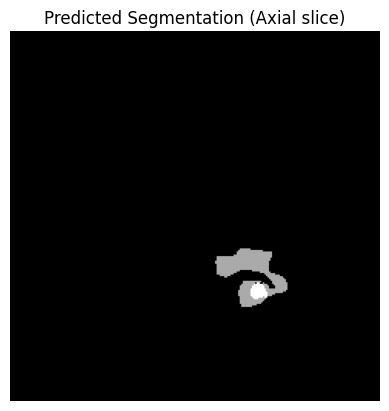

In [22]:
import nibabel as nib
import matplotlib.pyplot as plt

# Pick a predicted case
pred_file = "/kaggle/working/predictions/BraTS20_Training_003.nii"

# Load the predicted mask
pred_img = nib.load(pred_file)
pred_data = pred_img.get_fdata()

# Check shape
print("Prediction shape:", pred_data.shape)

# Visualize the middle slice in axial plane
mid_slice = pred_data.shape[2] // 2
plt.imshow(pred_data[:, :, mid_slice], cmap='gray')
plt.title("Predicted Segmentation (Axial slice)")
plt.axis("off")
plt.show()


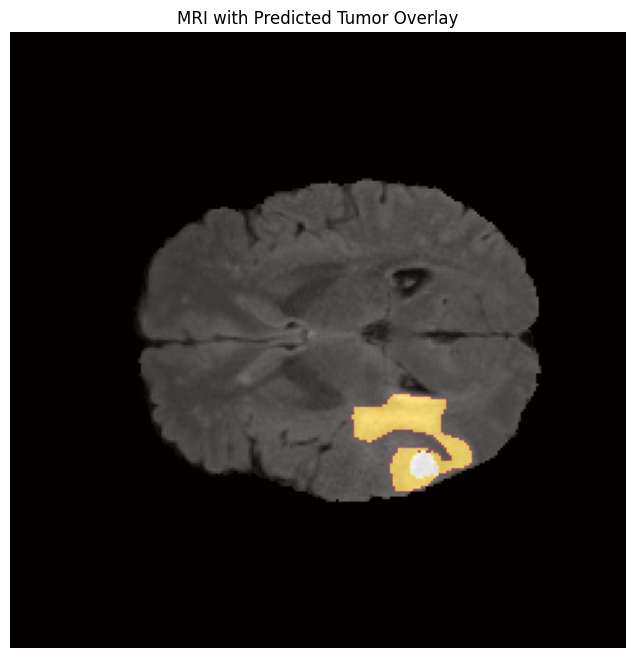

In [23]:
import nibabel as nib
import matplotlib.pyplot as plt
%matplotlib inline

# Load MRI channel 0 (e.g., flair or t1ce) and predicted mask
mri_file = "/kaggle/working/nnUNet_raw_data_base/nnUNet_raw/Dataset001_BraTS2020/imagesTr/BraTS20_Training_003_0000.nii"
pred_file = "/kaggle/working/predictions/BraTS20_Training_003.nii"

mri = nib.load(mri_file).get_fdata()
pred = nib.load(pred_file).get_fdata()

# Choose axial slice
z_mid = mri.shape[2] // 2

plt.figure(figsize=(8, 8))
plt.imshow(mri[:, :, z_mid], cmap='gray')  # show brain
plt.imshow(pred[:, :, z_mid], cmap='hot', alpha=0.5)  # overlay tumor
plt.title("MRI with Predicted Tumor Overlay")
plt.axis("off")
plt.show()
